<a href="https://colab.research.google.com/github/dilliganeshrishi-1025/BOTTLE-CAP-DEFECT-DETECTION/blob/main/notebooks/bottle_cap_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile('/content/bottle-cap.v3i.yolov8.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

BadZipFile: File is not a zip file

In [ ]:
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['Broken Cap', 'Broken Ring', 'Good Cap', 'Loose Cap', 'No Cap']

roboflow:
  workspace: project-jxzvy
  project: bottle-cap-iuzcs
  version: 3
  license: MIT
  url: https://universe.roboflow.com/project-jxzvy/bottle-cap-iuzcs/dataset/3


In [ ]:
import os
import shutil

# Class ID -> binary label mapping (from your data.yaml)
# 0: Broken Cap, 1: Broken Ring, 2: Good Cap, 3: Loose Cap, 4: No Cap
CLASS_MAP = {
    0: 'defective',  # Broken Cap
    1: 'defective',  # Broken Ring
    2: 'good',        # Good Cap
    3: 'defective',  # Loose Cap
    4: 'defective',  # No Cap
}

# Change this if your dataset folder is named differently
BASE_DIR = '/content/dataset'
OUTPUT_DIR = '/content/dataset_binary'
SPLITS = ['train', 'valid', 'test']

counts = {}

for split in SPLITS:
    images_dir = os.path.join(BASE_DIR, split, 'images')
    labels_dir = os.path.join(BASE_DIR, split, 'labels')

    if not os.path.isdir(images_dir):
        print(f"Skipping {split}: folder not found at {images_dir}")
        continue

    counts[split] = {'good': 0, 'defective': 0}

    for label_file in os.listdir(labels_dir):
        if not label_file.endswith('.txt'):
            continue

        label_path = os.path.join(labels_dir, label_file)
        image_name = label_file.replace('.txt', '.jpg')  # adjust if images are .png
        image_path = os.path.join(images_dir, image_name)

        # if .jpg doesn't exist, try .png
        if not os.path.exists(image_path):
            image_name_png = label_file.replace('.txt', '.png')
            image_path_png = os.path.join(images_dir, image_name_png)
            if os.path.exists(image_path_png):
                image_path = image_path_png
                image_name = image_name_png
            else:
                print(f"Warning: no matching image for {label_file}")
                continue

        # Read the first class ID found in this label file
        # (if an image has multiple defect boxes, we still treat the whole
        # image as 'defective' if ANY defect class appears)
        with open(label_path, 'r') as f:
            lines = f.readlines()

        if not lines:
            continue

        class_ids = [int(line.split()[0]) for line in lines if line.strip()]

        # If any box in the image is a defect class, mark whole image defective
        if any(CLASS_MAP[cid] == 'defective' for cid in class_ids):
            label = 'defective'
        else:
            label = 'good'

        dest_dir = os.path.join(OUTPUT_DIR, split, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(image_path, os.path.join(dest_dir, image_name))

        counts[split][label] += 1

print("\n=== Class counts per split ===")
for split, c in counts.items():
    total = c['good'] + c['defective']
    print(f"{split}: good={c['good']}, defective={c['defective']}, total={total}")


=== Class counts per split ===
train: good=460, defective=742, total=1202
valid: good=44, defective=72, total=116
test: good=25, defective=89, total=114


In [ ]:
import os
from PIL import Image
import hashlib

BASE_DIR = '/content/dataset_binary'
SPLITS = ['train', 'valid', 'test']
CLASSES = ['good', 'defective']

corrupt_files = []
resolutions = {}
hashes = {}
duplicates = []

total_checked = 0

for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(BASE_DIR, split, cls)
        if not os.path.isdir(folder):
            continue

        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            total_checked += 1

            # Check 1: Corrupt / unreadable images
            try:
                img = Image.open(fpath)
                img.verify()  # checks file integrity
                img = Image.open(fpath)  # reopen after verify (verify closes it)
                w, h = img.size
            except Exception as e:
                corrupt_files.append(fpath)
                continue

            # Check 2: Resolution tracking
            res = f"{w}x{h}"
            resolutions[res] = resolutions.get(res, 0) + 1

            # Check 3: Duplicate detection (via file hash)
            with open(fpath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in hashes:
                duplicates.append((fpath, hashes[file_hash]))
            else:
                hashes[file_hash] = fpath

print(f"=== Data Quality Report ===")
print(f"Total images checked: {total_checked}")
print(f"\nCorrupt/unreadable images: {len(corrupt_files)}")
for f in corrupt_files[:10]:
    print(f"  - {f}")

print(f"\nResolution breakdown (top 10 most common):")
sorted_res = sorted(resolutions.items(), key=lambda x: -x[1])
for res, count in sorted_res[:10]:
    print(f"  {res}: {count} images")
print(f"  Total unique resolutions: {len(resolutions)}")

print(f"\nExact duplicate images found: {len(duplicates)}")
for f1, f2 in duplicates[:10]:
    print(f"  - {f1}  ==  {f2}")

=== Data Quality Report ===
Total images checked: 1432

Corrupt/unreadable images: 0

Resolution breakdown (top 10 most common):
  640x640: 1432 images
  Total unique resolutions: 1

Exact duplicate images found: 0


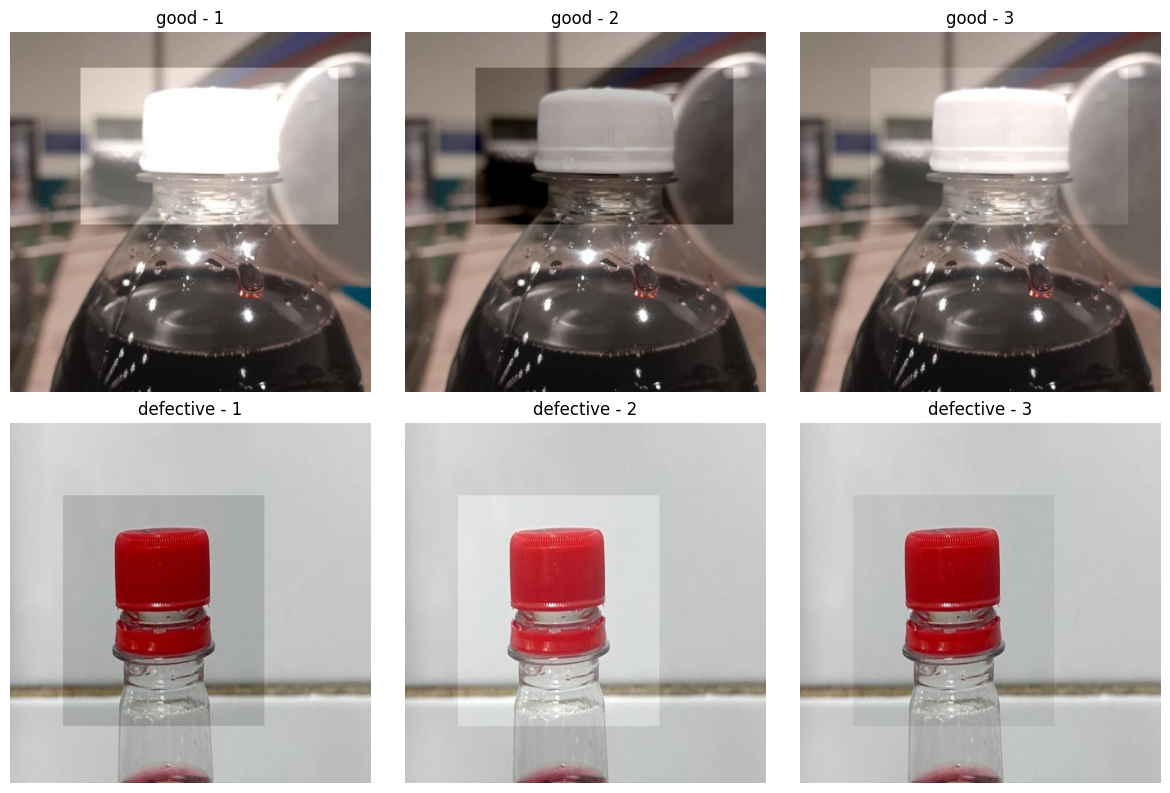


Sample images copied to: /content/ppt_samples
You can now download them via the Colab file browser (left sidebar),
or right-click 'sample_grid.png' in /content/ to download the combined preview image.


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import shutil

BASE_DIR = '/content/dataset_binary/train'  # using train split, has the most images
CLASSES = ['good', 'defective']
NUM_SAMPLES = 3

# Folder to collect the picked samples into (so you can download them easily)
SAMPLE_OUTPUT_DIR = '/content/ppt_samples'
os.makedirs(SAMPLE_OUTPUT_DIR, exist_ok=True)

fig, axes = plt.subplots(len(CLASSES), NUM_SAMPLES, figsize=(12, 8))

for row, cls in enumerate(CLASSES):
    folder = os.path.join(BASE_DIR, cls)
    files = sorted(os.listdir(folder))[:NUM_SAMPLES]  # first N images

    for col, fname in enumerate(files):
        fpath = os.path.join(folder, fname)
        img = Image.open(fpath)

        # Show in the grid
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls} - {col+1}")
        axes[row, col].axis('off')

        # Also copy the actual file out so you can download it directly
        out_name = f"{cls}_{col+1}.jpg"
        shutil.copy(fpath, os.path.join(SAMPLE_OUTPUT_DIR, out_name))

plt.tight_layout()
plt.savefig('/content/sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSample images copied to: {SAMPLE_OUTPUT_DIR}")
print("You can now download them via the Colab file browser (left sidebar),")
print("or right-click 'sample_grid.png' in /content/ to download the combined preview image.")

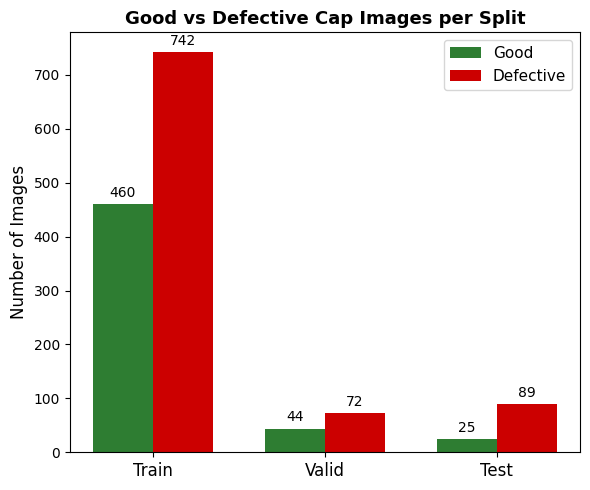

Chart saved to /content/class_distribution_chart.png
Download it from the Colab file browser (left sidebar) and paste it into Slide 6.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your actual counts from the earlier script
splits = ['Train', 'Valid', 'Test']
good_counts = [460, 44, 25]
defective_counts = [742, 72, 89]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))

bars1 = ax.bar(x - width/2, good_counts, width, label='Good', color='#2E7D32')
bars2 = ax.bar(x + width/2, defective_counts, width, label='Defective', color='#CC0000')

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Good vs Defective Cap Images per Split', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=12)
ax.legend(fontsize=11)

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/class_distribution_chart.png', dpi=200, bbox_inches='tight')
plt.show()

print("Chart saved to /content/class_distribution_chart.png")
print("Download it from the Colab file browser (left sidebar) and paste it into Slide 6.")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# STEP 1: Data loading with augmentation
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32
BASE_DIR = '/content/dataset_binary'

# Training data: apply augmentation (rotation, flip, zoom, brightness)
# Why these specific augmentations:
# - rotation/zoom: camera angle/distance varies on a real line
# - horizontal_flip: cap orientation doesn't matter, safe to flip
# - NO vertical_flip: a bottle upside-down is not realistic
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
)

# Validation/Test data: NO augmentation, only preprocessing
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    f'{BASE_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],  # good=0, defective=1
    shuffle=True,
)

val_generator = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],
    shuffle=False,
)

print("Class indices (label mapping):", train_generator.class_indices)

# ============================================================
# STEP 2: Compute class weights (handles imbalance)
# ============================================================
train_labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights (to handle imbalance):", class_weights)

# ============================================================
# STEP 3: Build the model (MobileNetV2 transfer learning)
# ============================================================
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base layers initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # binary: good=0, defective=1

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'),
              tf.keras.metrics.Precision(name='precision')]
)

model.summary()

# ============================================================
# STEP 4: Train
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# Save the trained model
model.save('/content/bottle_cap_model.h5')
print("\nModel saved to /content/bottle_cap_model.h5")

Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Class indices (label mapping): {'good': 0, 'defective': 1}


IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
import zipfile

with zipfile.ZipFile('/content/bottle-cap.v3i.yolov8.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Unzip done!")

Unzip done!


In [ ]:
import os
import shutil

# Class ID -> binary label mapping (from your data.yaml)
# 0: Broken Cap, 1: Broken Ring, 2: Good Cap, 3: Loose Cap, 4: No Cap
CLASS_MAP = {
    0: 'defective',  # Broken Cap
    1: 'defective',  # Broken Ring
    2: 'good',        # Good Cap
    3: 'defective',  # Loose Cap
    4: 'defective',  # No Cap
}

# Change this if your dataset folder is named differently
BASE_DIR = '/content/dataset'
OUTPUT_DIR = '/content/dataset_binary'
SPLITS = ['train', 'valid', 'test']

counts = {}

for split in SPLITS:
    images_dir = os.path.join(BASE_DIR, split, 'images')
    labels_dir = os.path.join(BASE_DIR, split, 'labels')

    if not os.path.isdir(images_dir):
        print(f"Skipping {split}: folder not found at {images_dir}")
        continue

    counts[split] = {'good': 0, 'defective': 0}

    for label_file in os.listdir(labels_dir):
        if not label_file.endswith('.txt'):
            continue

        label_path = os.path.join(labels_dir, label_file)
        image_name = label_file.replace('.txt', '.jpg')
        image_path = os.path.join(images_dir, image_name)

        if not os.path.exists(image_path):
            image_name_png = label_file.replace('.txt', '.png')
            image_path_png = os.path.join(images_dir, image_name_png)
            if os.path.exists(image_path_png):
                image_path = image_path_png
                image_name = image_name_png
            else:
                print(f"Warning: no matching image for {label_file}")
                continue

        with open(label_path, 'r') as f:
            lines = f.readlines()

        if not lines:
            continue

        class_ids = [int(line.split()[0]) for line in lines if line.strip()]

        if any(CLASS_MAP[cid] == 'defective' for cid in class_ids):
            label = 'defective'
        else:
            label = 'good'

        dest_dir = os.path.join(OUTPUT_DIR, split, label)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(image_path, os.path.join(dest_dir, image_name))

        counts[split][label] += 1

print("\n=== Class counts per split ===")
for split, c in counts.items():
    total = c['good'] + c['defective']
    print(f"{split}: good={c['good']}, defective={c['defective']}, total={total}")


=== Class counts per split ===
train: good=460, defective=742, total=1202
valid: good=44, defective=72, total=116
test: good=25, defective=89, total=114


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# STEP 1: Data loading with augmentation
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 32
BASE_DIR = '/content/dataset_binary'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    f'{BASE_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],
    shuffle=True,
)

val_generator = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['good', 'defective'],
    shuffle=False,
)

print("Class indices (label mapping):", train_generator.class_indices)

# ============================================================
# STEP 2: Compute class weights (handles imbalance)
# ============================================================
train_labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights (to handle imbalance):", class_weights)

# ============================================================
# STEP 3: Build the model (MobileNetV2 transfer learning)
# ============================================================
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'),
              tf.keras.metrics.Precision(name='precision')]
)

model.summary()

# ============================================================
# STEP 4: Train
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

model.save('/content/bottle_cap_model.h5')
print("\nModel saved to /content/bottle_cap_model.h5")

Found 1202 images belonging to 2 classes.
Found 116 images belonging to 2 classes.
Found 114 images belonging to 2 classes.
Class indices (label mapping): {'good': 0, 'defective': 1}
Class weights (to handle imbalance): {0: np.float64(1.3065217391304347), 1: np.float64(0.8099730458221024)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8020 - loss: 0.4342 - precision: 0.9078 - recall: 0.7561 - val_accuracy: 0.6379 - val_loss: 0.5115 - val_precision: 0.6316 - val_recall: 1.0000
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 594ms/step - accuracy: 0.8760 - loss: 0.3027 - precision: 0.9367 - recall: 0.8571 - val_accuracy: 0.6466 - val_loss: 0.4823 - val_precision: 0.6372 - val_recall: 1.0000
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 568ms/step - accuracy: 0.9160 - loss: 0.2273 - precision: 0.9585 - recall: 0.9030 - val_accuracy: 0.8103 - val_loss: 0.4135 - val_precision: 0.7778 - val_recall: 0.9722
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 580ms/step - accuracy: 0.9101 - loss: 0.2142 - precision: 0.9490 - recall: 0.9030 - val_accuracy: 0.8362 - val_loss: 0.3901 - val_precision: 0.7978 - val_recall: 0.9861
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 596ms/step - accuracy: 0.9260 - loss: 0.1962 - precision: 0.9618 - recall: 0.9164 - val_accuracy: 0.8362 - val_loss: 


Model saved to /content/bottle_cap_model.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


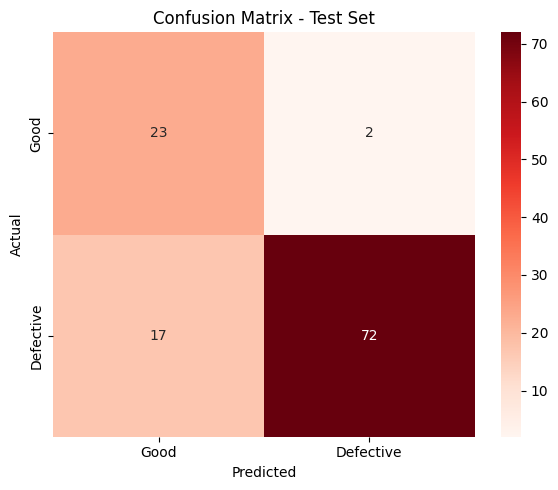

=== Manufacturing KPI Results (Test Set) ===
Defect Detection Rate (Recall): 80.90%  (Target: >=90%)
False Positive Rate:            8.00%  (Target: <10%)
Precision:                      97.30%

Confusion Matrix breakdown:
  True Negatives (Good correctly passed):     23
  False Positives (Good wrongly flagged):     2
  False Negatives (Defective MISSED - risky): 17
  True Positives (Defective correctly caught): 72

=== Full Classification Report ===
              precision    recall  f1-score   support

        Good       0.57      0.92      0.71        25
   Defective       0.97      0.81      0.88        89

    accuracy                           0.83       114
   macro avg       0.77      0.86      0.80       114
weighted avg       0.89      0.83      0.84       114



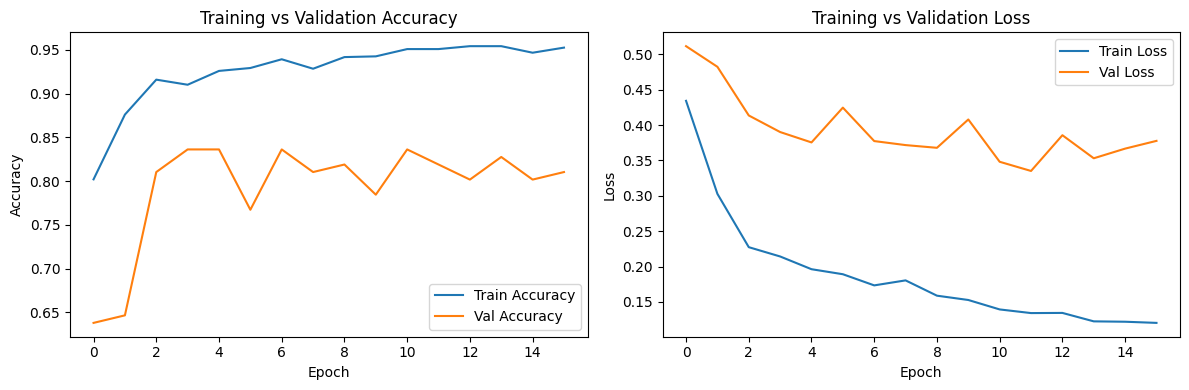


Saved: /content/confusion_matrix.png and /content/training_curves.png
Download these from the Colab file browser for your Review 2 report/PPT.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Evaluate on the held-out TEST set
# ============================================================
test_generator.reset()
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

# Class mapping: 0 = good, 1 = defective
class_names = ['Good', 'Defective']

# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Manufacturing-relevant metrics ---
tn, fp, fn, tp = cm.ravel()
# Here: class 1 = Defective (the "positive" class we care about catching)

defect_detection_rate = tp / (tp + fn)  # Recall on Defective
false_positive_rate = fp / (fp + tn)     # Good caps wrongly flagged
precision = tp / (tp + fp)

print("=== Manufacturing KPI Results (Test Set) ===")
print(f"Defect Detection Rate (Recall): {defect_detection_rate:.2%}  (Target: >=90%)")
print(f"False Positive Rate:            {false_positive_rate:.2%}  (Target: <10%)")
print(f"Precision:                      {precision:.2%}")
print(f"\nConfusion Matrix breakdown:")
print(f"  True Negatives (Good correctly passed):     {tn}")
print(f"  False Positives (Good wrongly flagged):     {fp}")
print(f"  False Negatives (Defective MISSED - risky): {fn}")
print(f"  True Positives (Defective correctly caught): {tp}")

print("\n=== Full Classification Report ===")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# --- Training curves ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nSaved: /content/confusion_matrix.png and /content/training_curves.png")
print("Download these from the Colab file browser for your Review 2 report/PPT.")

In [ ]:
import tensorflow as tf

# ============================================================
# FINE-TUNING: Unfreeze the top layers of MobileNetV2
# ============================================================
# Unfreeze the last ~30 layers of the base model so they can adapt
# to bottle-cap-specific features, instead of staying fully generic.
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile with a MUCH lower learning rate (important!)
# A high learning rate here would destroy the pretrained weights.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'),
              tf.keras.metrics.Precision(name='precision')]
)

print("Fine-tuning: unfrozen last 30 layers of MobileNetV2")
print(f"Trainable layers now: {sum(l.trainable for l in base_model.layers)}")

# ============================================================
# Continue training (fine-tune for fewer epochs)
# ============================================================
early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop_ft]
)

model.save('/content/bottle_cap_model_finetuned.h5')
print("\nFine-tuned model saved to /content/bottle_cap_model_finetuned.h5")

Fine-tuning: unfrozen last 30 layers of MobileNetV2
Trainable layers now: 30
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8827 - loss: 0.3008 - precision: 0.8908 - recall: 0.9232 - val_accuracy: 0.8017 - val_loss: 0.3912 - val_precision: 0.9804 - val_recall: 0.6944
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 565ms/step - accuracy: 0.9301 - loss: 0.1897 - precision: 0.9634 - recall: 0.9218 - val_accuracy: 0.7845 - val_loss: 0.4752 - val_precision: 0.9796 - val_recall: 0.6667
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 578ms/step - accuracy: 0.9351 - loss: 0.1634 - precision: 0.9703 - recall: 0.9232 - val_accuracy: 0.7586 - val_loss: 0.5695 - val_precision: 0.9783 - val_recall: 0.6250
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 608ms/step - accuracy: 0.9484 - loss: 0.1439 - precision: 0.9843 - recall: 0.9313 - val_accuracy: 0.7500 - val_loss: 0.5902 - val_precision: 0.9778 - val_recall: 0.6111



Fine-tuned model saved to /content/bottle_cap_model_finetuned.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step 


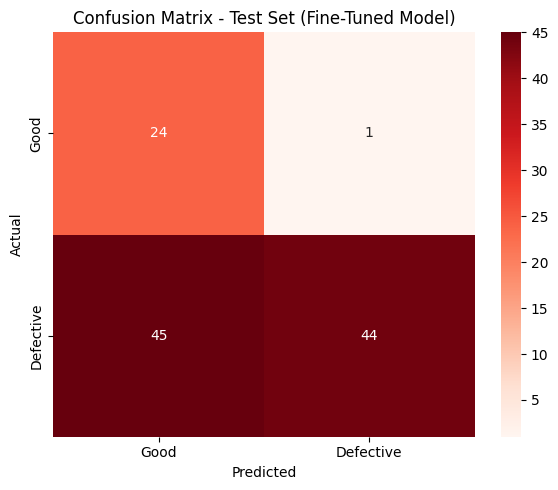

=== Fine-Tuned Model: Manufacturing KPI Results (Test Set) ===
Defect Detection Rate (Recall): 49.44%  (Target: >=90%)
False Positive Rate:            4.00%  (Target: <10%)
Precision:                      97.78%

Confusion Matrix breakdown:
  True Negatives (Good correctly passed):     24
  False Positives (Good wrongly flagged):     1
  False Negatives (Defective MISSED - risky): 45
  True Positives (Defective correctly caught): 44

=== Full Classification Report ===
              precision    recall  f1-score   support

        Good       0.35      0.96      0.51        25
   Defective       0.98      0.49      0.66        89

    accuracy                           0.60       114
   macro avg       0.66      0.73      0.58       114
weighted avg       0.84      0.60      0.62       114


=== COMPARISON ===
Before fine-tuning: Recall=80.9%, FPR=8.0%, Precision=97.3%
After fine-tuning:  Recall=49.4%, FPR=4.0%, Precision=97.8%


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Evaluate FINE-TUNED model on the held-out TEST set
# ============================================================
test_generator.reset()
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

class_names = ['Good', 'Defective']

# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set (Fine-Tuned Model)')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_finetuned.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Manufacturing-relevant metrics ---
tn, fp, fn, tp = cm.ravel()

defect_detection_rate = tp / (tp + fn)
false_positive_rate = fp / (fp + tn)
precision = tp / (tp + fp)

print("=== Fine-Tuned Model: Manufacturing KPI Results (Test Set) ===")
print(f"Defect Detection Rate (Recall): {defect_detection_rate:.2%}  (Target: >=90%)")
print(f"False Positive Rate:            {false_positive_rate:.2%}  (Target: <10%)")
print(f"Precision:                      {precision:.2%}")
print(f"\nConfusion Matrix breakdown:")
print(f"  True Negatives (Good correctly passed):     {tn}")
print(f"  False Positives (Good wrongly flagged):     {fp}")
print(f"  False Negatives (Defective MISSED - risky): {fn}")
print(f"  True Positives (Defective correctly caught): {tp}")

print("\n=== Full Classification Report ===")
print(classification_report(true_labels, pred_labels, target_names=class_names))

print("\n=== COMPARISON ===")
print("Before fine-tuning: Recall=80.9%, FPR=8.0%, Precision=97.3%")
print(f"After fine-tuning:  Recall={defect_detection_rate:.1%}, FPR={false_positive_rate:.1%}, Precision={precision:.1%}")